# **SMART MOBILE PHONE PREDICTION USING MACHNE LEARNING**

## **Team - THE BOYS**

### Models Included:

* Decision Tree
* KNN
* Logistic Regression
* Gaussian Naive Bayes
* SVM
* Random Forest

**IMPORTING LIBRARIES**

In [2]:
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

from sklearn.model_selection import train_test_split


In [3]:
from sklearn.tree import DecisionTreeClassifier

from sklearn.neighbors import KNeighborsClassifier

from sklearn.linear_model import LogisticRegression

from sklearn.naive_bayes import GaussianNB

from sklearn.svm import SVC

from sklearn.ensemble import RandomForestClassifier

In [4]:
from sklearn.metrics import accuracy_score

from sklearn.metrics import confusion_matrix

**Reading Data**

In [5]:
data=pd.read_csv(r'data.csv')

X=data.drop('price_range',axis=1) # X contains all the features used for training
Y=data['price_range'] # Y contains the target for the features of X 

**Splitting the Data into Training and Testing**

In [6]:
X_train,X_test,Y_train,Y_test=train_test_split(X,Y,test_size=0.2,random_state=1)

# X_train contains the features used for training the model
# Y_train contains the target for the features of X_train which is used in training

# X_test contains  the features used for testing the model
# Y_test contains the target for the features of X_test which is used in testing. This Y_test is used to check the accuracy of the model while predicting the target for the X_test data.

**Scaling the Data** 

In [7]:
std=StandardScaler()

X_train_std=std.fit_transform(X_train)
X_test_std=std.transform(X_test)

### **EXPLORATORY DATA ANALYSIS**

In [8]:
X_train

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,842,0,2.2,0,1,0,7,0.6,188,2,2,20,756,2549,9,7,19,0,0,1
816,805,1,0.7,0,0,0,64,0.1,97,4,14,641,704,418,11,6,17,0,1,1
790,911,1,2.9,0,0,0,46,0.1,181,5,1,461,670,363,9,5,17,0,1,0
361,899,0,0.5,1,13,1,57,0.9,172,2,18,788,1331,364,11,1,7,1,1,0
592,1263,0,0.5,0,12,0,64,0.3,175,5,18,178,1883,1183,14,3,17,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1791,1203,1,0.5,1,0,1,11,0.9,109,2,12,35,510,1672,17,13,19,1,1,0
1096,1154,0,2.0,0,6,1,35,0.8,159,5,16,1003,1827,3262,16,15,16,1,0,0
1932,718,1,1.6,1,1,1,30,0.4,93,3,12,662,997,1601,10,9,12,1,1,1
235,1523,1,1.8,0,6,1,11,0.1,129,1,8,148,1606,707,19,8,19,1,1,0


In [9]:
X_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 1600 entries, 0 to 1061
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  1600 non-null   int64  
 1   blue           1600 non-null   int64  
 2   clock_speed    1600 non-null   float64
 3   dual_sim       1600 non-null   int64  
 4   fc             1600 non-null   int64  
 5   four_g         1600 non-null   int64  
 6   int_memory     1600 non-null   int64  
 7   m_dep          1600 non-null   float64
 8   mobile_wt      1600 non-null   int64  
 9   n_cores        1600 non-null   int64  
 10  pc             1600 non-null   int64  
 11  px_height      1600 non-null   int64  
 12  px_width       1600 non-null   int64  
 13  ram            1600 non-null   int64  
 14  sc_h           1600 non-null   int64  
 15  sc_w           1600 non-null   int64  
 16  talk_time      1600 non-null   int64  
 17  three_g        1600 non-null   int64  
 18  touch_sc

In [10]:
X_train.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
count,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000,1600.000000
mean,1247.944375,0.495625,1.512812,0.516875,4.308750,0.518125,32.389375,0.501313,139.647500,4.528750,9.867500,640.108750,1246.838125,2112.836250,12.306250,5.725000,10.975000,0.755000,0.510000,0.506875
std,435.784745,0.500137,0.816676,0.499871,4.332021,0.499828,18.179434,0.289926,35.046411,2.294551,6.059942,441.883112,433.819613,1093.525061,4.198926,4.359042,5.425889,0.430222,0.500056,0.500109
min,503.000000,0.000000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,0.000000,0.000000,500.000000,256.000000,5.000000,0.000000,2.000000,0.000000,0.000000,0.000000
25%,862.750000,0.000000,0.700000,0.000000,1.000000,0.000000,16.000000,0.200000,109.000000,3.000000,5.000000,278.000000,866.750000,1179.000000,9.000000,2.000000,6.000000,1.000000,0.000000,0.000000
50%,1250.000000,0.000000,1.500000,1.000000,3.000000,1.000000,32.000000,0.500000,139.000000,4.000000,10.000000,561.500000,1243.500000,2118.500000,12.000000,5.000000,11.000000,1.000000,1.000000,1.000000
75%,1620.000000,1.000000,2.200000,1.000000,7.000000,1.000000,48.250000,0.800000,169.000000,7.000000,15.000000,937.250000,1630.250000,3060.000000,16.000000,9.000000,16.000000,1.000000,1.000000,1.000000
max,1998.000000,1.000000,3.000000,1.000000,19.000000,1.000000,64.000000,1.000000,200.000000,8.000000,20.000000,1960.000000,1998.000000,3998.000000,19.000000,18.000000,20.000000,1.000000,1.000000,1.000000


In [11]:
X_train.shape

(1600, 20)

In [12]:
Y_train

0       1
816     0
790     0
361     0
592     1
       ..
1791    0
1096    3
1932    1
235     0
1061    1
Name: price_range, Length: 1600, dtype: int64

In [13]:
Y_train.info()

<class 'pandas.core.series.Series'>
Int64Index: 1600 entries, 0 to 1061
Series name: price_range
Non-Null Count  Dtype
--------------  -----
1600 non-null   int64
dtypes: int64(1)
memory usage: 25.0 KB


In [14]:
Y_train.describe()

count    1600.000000
mean        1.483750
std         1.119383
min         0.000000
25%         0.000000
50%         1.000000
75%         2.000000
max         3.000000
Name: price_range, dtype: float64

In [15]:
Y_train.shape

(1600,)

In [16]:
X_test

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
674,1034,0,2.6,1,2,1,45,0.3,190,3,4,182,1293,969,15,1,7,1,0,0
1699,1002,1,1.8,0,1,0,45,0.7,180,7,7,948,1007,1234,19,13,18,1,1,0
1282,609,1,0.5,0,4,1,10,0.1,81,6,6,113,1524,1905,16,3,18,1,1,1
1315,1510,0,0.6,1,1,0,32,0.7,135,3,8,963,1520,854,8,2,10,1,0,1
1210,805,1,1.7,1,0,1,58,0.9,168,3,10,81,1544,3397,7,6,2,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
400,1266,0,1.9,1,0,1,7,0.2,184,3,12,346,1468,2532,10,5,4,1,1,1
763,1741,1,1.8,0,0,0,14,0.7,143,8,0,730,1895,3387,11,3,3,1,0,0
385,1880,1,1.8,0,4,1,18,0.7,138,3,5,71,699,3333,17,15,7,1,0,0
1667,1967,0,0.5,0,0,1,46,0.6,199,1,7,518,1374,1567,15,2,7,1,1,0


In [17]:
X_test.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 400 entries, 674 to 1820
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  400 non-null    int64  
 1   blue           400 non-null    int64  
 2   clock_speed    400 non-null    float64
 3   dual_sim       400 non-null    int64  
 4   fc             400 non-null    int64  
 5   four_g         400 non-null    int64  
 6   int_memory     400 non-null    int64  
 7   m_dep          400 non-null    float64
 8   mobile_wt      400 non-null    int64  
 9   n_cores        400 non-null    int64  
 10  pc             400 non-null    int64  
 11  px_height      400 non-null    int64  
 12  px_width       400 non-null    int64  
 13  ram            400 non-null    int64  
 14  sc_h           400 non-null    int64  
 15  sc_w           400 non-null    int64  
 16  talk_time      400 non-null    int64  
 17  three_g        400 non-null    int64  
 18  touch_s

In [18]:
X_test.describe()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
count,400.000000,400.00000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000000,400.000,400.00000
mean,1200.815000,0.49250,1.560000,0.480000,4.312500,0.535000,30.675000,0.503500,142.655000,4.487500,10.112500,665.105000,1270.225000,2169.720000,12.307500,5.935000,11.155000,0.787500,0.475,0.50750
std,452.255313,0.50057,0.813236,0.500226,4.384393,0.499398,17.967372,0.282644,36.725303,2.263327,6.085427,451.297488,425.679388,1048.923098,4.275353,4.347185,5.618264,0.409589,0.500,0.50057
min,501.000000,0.00000,0.500000,0.000000,0.000000,0.000000,2.000000,0.100000,80.000000,1.000000,0.000000,3.000000,506.000000,259.000000,5.000000,0.000000,2.000000,0.000000,0.000,0.00000
25%,814.750000,0.00000,0.700000,0.000000,1.000000,0.000000,15.000000,0.300000,111.000000,3.000000,5.000000,294.500000,898.250000,1281.250000,9.000000,2.000000,6.000000,1.000000,0.000,0.00000
50%,1159.000000,0.00000,1.600000,0.000000,3.000000,1.000000,30.000000,0.500000,145.000000,4.000000,10.000000,584.000000,1260.000000,2296.500000,12.000000,5.000000,11.000000,1.000000,0.000,1.00000
75%,1580.500000,1.00000,2.300000,1.000000,7.000000,1.000000,45.000000,0.800000,177.000000,6.000000,15.250000,967.000000,1639.000000,3077.250000,16.000000,9.000000,16.000000,1.000000,1.000,1.00000
max,1997.000000,1.00000,3.000000,1.000000,18.000000,1.000000,64.000000,1.000000,200.000000,8.000000,20.000000,1914.000000,1995.000000,3984.000000,19.000000,18.000000,20.000000,1.000000,1.000,1.00000


In [19]:
X_test.shape

(400, 20)

In [20]:
Y_test

674     0
1699    0
1282    1
1315    1
1210    2
       ..
400     2
763     3
385     3
1667    1
1820    0
Name: price_range, Length: 400, dtype: int64

In [21]:
Y_test.info()

<class 'pandas.core.series.Series'>
Int64Index: 400 entries, 674 to 1820
Series name: price_range
Non-Null Count  Dtype
--------------  -----
400 non-null    int64
dtypes: int64(1)
memory usage: 6.2 KB


In [22]:
Y_test.describe()

count    400.000000
mean       1.565000
std        1.113046
min        0.000000
25%        1.000000
50%        2.000000
75%        3.000000
max        3.000000
Name: price_range, dtype: float64

In [23]:
Y_test.shape

(400,)

### **DATA VISUALISATION**

**Price vs RAM**

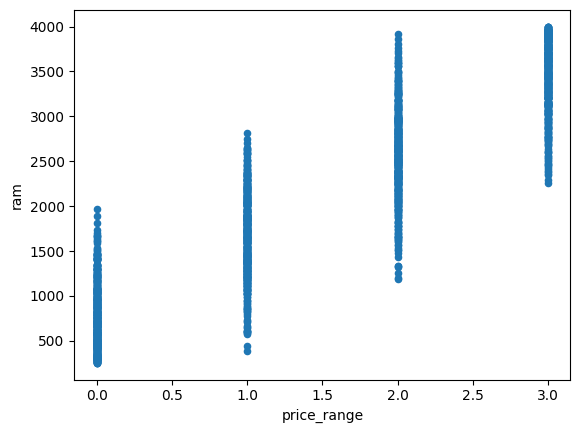

In [24]:
data.plot(x='price_range',y='ram',kind='scatter')
plt.show()

**Price vs Batter Power**

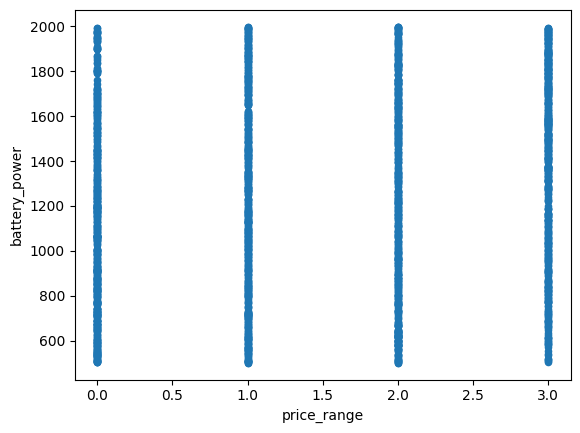

In [25]:
data.plot(x='price_range',y='battery_power',kind='scatter')
plt.show()

**Price vs Front Camera**

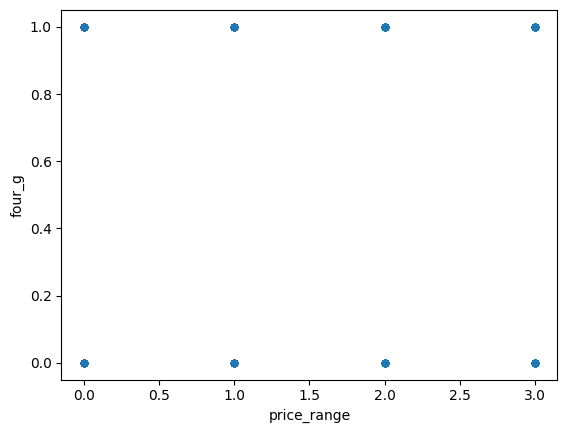

In [26]:
data.plot(x='price_range',y='four_g',kind='scatter')
plt.show()

**Overview**

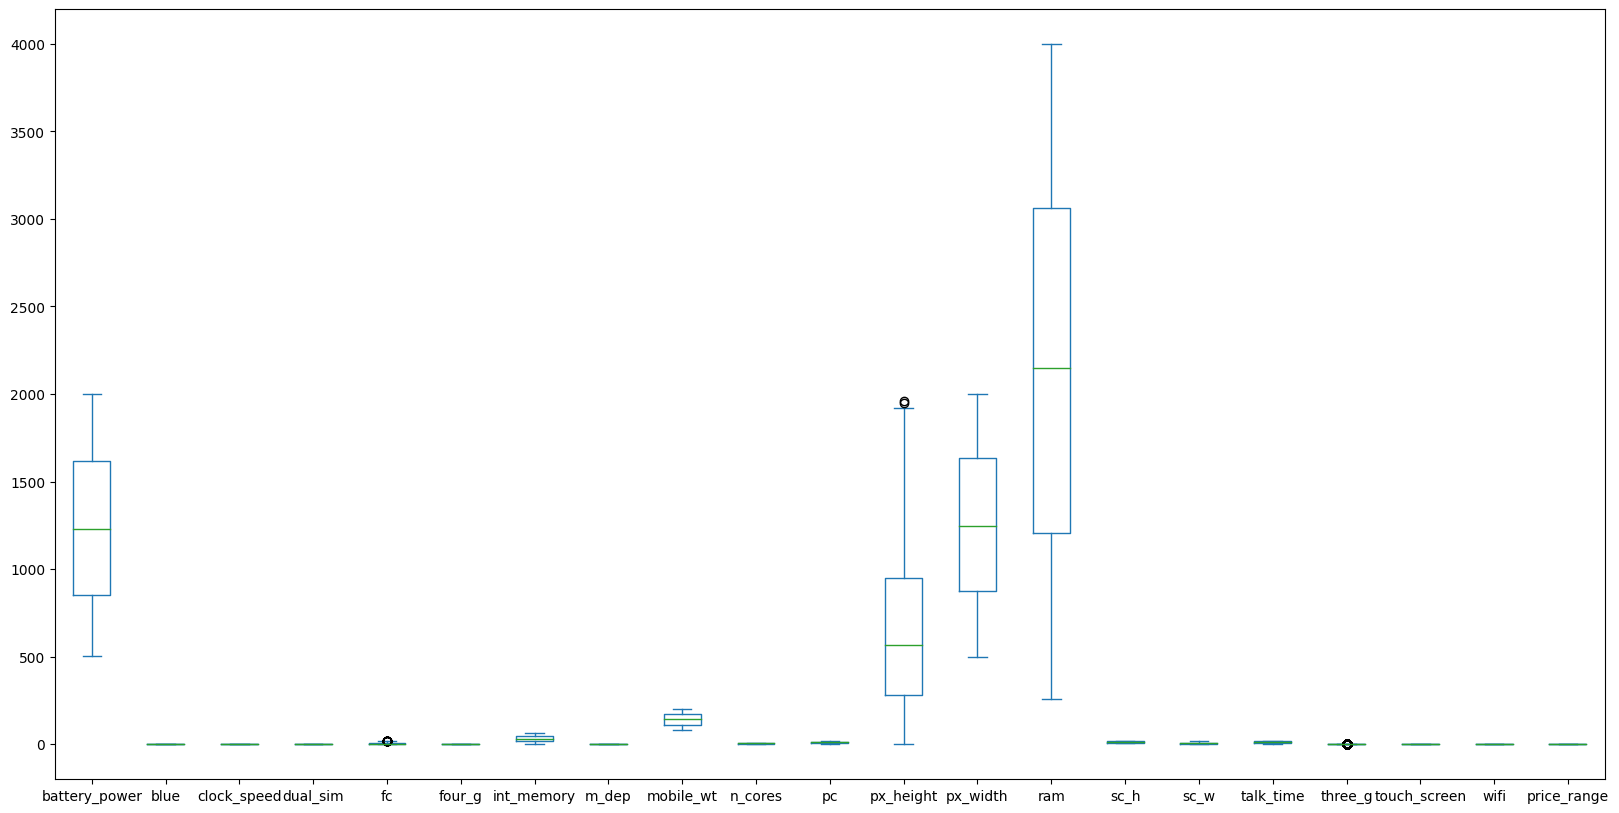

In [27]:
data.plot(kind='box',figsize=(20,10))
plt.show()

### **MODEL TRAINING**

**Decision Tree**

In [28]:
dt=DecisionTreeClassifier()

dt.fit(X_train,Y_train)
Y_pred = dt.predict(X_test)

**Decision Tree Metrics**

In [29]:
#Accuracy
dt_ac=accuracy_score(Y_test,Y_pred)
print('Decision Tree Accuracy:',dt_ac)

#Confusion Matrix
print('Decision Tree Confusion Matrix:\n',confusion_matrix(Y_test,Y_pred))

Decision Tree Accuracy: 0.86
Decision Tree Confusion Matrix:
 [[84  8  0  0]
 [ 8 82  6  0]
 [ 0 14 85  7]
 [ 0  0 13 93]]


**KNN**

In [30]:
knn=KNeighborsClassifier()

knn.fit(X_train,Y_train)
Y_pred = knn.predict(X_test)

C:\Users\nagas\AppData\Roaming\Python\Python38\site-packages\sklearn\neighbors\_classification.py:228: FutureWarning: Unlike other reduction functions (e.g. `skew`, `kurtosis`), the default behavior of `mode` typically preserves the axis it acts along. In SciPy 1.11.0, this behavior will change: the default value of `keepdims` will become False, the `axis` over which the statistic is taken will be eliminated, and the value None will no longer be accepted. Set `keepdims` to True or False to avoid this warning.
  mode, _ = stats.mode(_y[neigh_ind, k], axis=1)


In [31]:
#Accuracy
knn_ac=accuracy_score(Y_test,Y_pred)
print('KNN Accuracy:',knn_ac)

#Confusion Matrix
print('KNN Confusion Matrix:\n',confusion_matrix(Y_test,Y_pred))

KNN Accuracy: 0.9125
KNN Confusion Matrix:
 [[89  3  0  0]
 [ 2 90  4  0]
 [ 0  7 95  4]
 [ 0  0 15 91]]


**Logistic Regression**

In [32]:
lr=LogisticRegression()

lr.fit(X_train_std,Y_train)
Y_pred=lr.predict(X_test_std)

In [33]:
#Accuracy
lr_ac=accuracy_score(Y_test,Y_pred)
print('Logistic Regression Accuracy:',lr_ac)

#Confusion Matrix
print('Logistic Regression Confusion Matrix:\n',confusion_matrix(Y_test,Y_pred))

Logistic Regression Accuracy: 0.96
Logistic Regression Confusion Matrix:
 [[ 91   1   0   0]
 [  3  92   1   0]
 [  0   6  99   1]
 [  0   0   4 102]]


**Gaussian Naive Bayes**

In [34]:
gnb = GaussianNB()

gnb.fit(X_train,Y_train)
Y_pred=gnb.predict(X_test)

In [35]:
#Accuracy
gnb_ac=accuracy_score(Y_test,Y_pred)
print('Naive Bayes Accuracy:',gnb_ac)

#Confusion Matrix
print('Gaussian Naive Bayes Confusion Matrix:\n',confusion_matrix(Y_test,Y_pred))

Naive Bayes Accuracy: 0.7575
Gaussian Naive Bayes Confusion Matrix:
 [[79 13  0  0]
 [11 66 19  0]
 [ 0 21 72 13]
 [ 0  1 19 86]]


**SVM**

In [36]:
svm = SVC(kernel='linear')

svm.fit(X_train,Y_train)
Y_pred=svm.predict(X_test)

In [37]:
#Accuracy
svm_ac=accuracy_score(Y_test,Y_pred)
print('SVM Accuracy:',svm_ac)

#Confusion Matrix
print('SVM Confusion Matrix:\n',confusion_matrix(Y_test,Y_pred))

SVM Accuracy: 0.9625
SVM Confusion Matrix:
 [[ 90   2   0   0]
 [  2  92   2   0]
 [  0   4 101   1]
 [  0   0   4 102]]


**Random Forest**

In [38]:
rf = RandomForestClassifier()

rf.fit(X_train,Y_train)
Y_pred=rf.predict(X_test)

In [39]:
#Accuracy
rf_ac=accuracy_score(Y_test,Y_pred)
print('Random Forest Accuracy:',rf_ac)

#Confusion Matrix
print('Random Forest Confusion Matrix:\n',confusion_matrix(Y_test,Y_pred))

Random Forest Accuracy: 0.8675
Random Forest Confusion Matrix:
 [[85  7  0  0]
 [ 8 79  9  0]
 [ 0 13 89  4]
 [ 0  0 12 94]]


Text(0, 0.5, 'Accuracy')

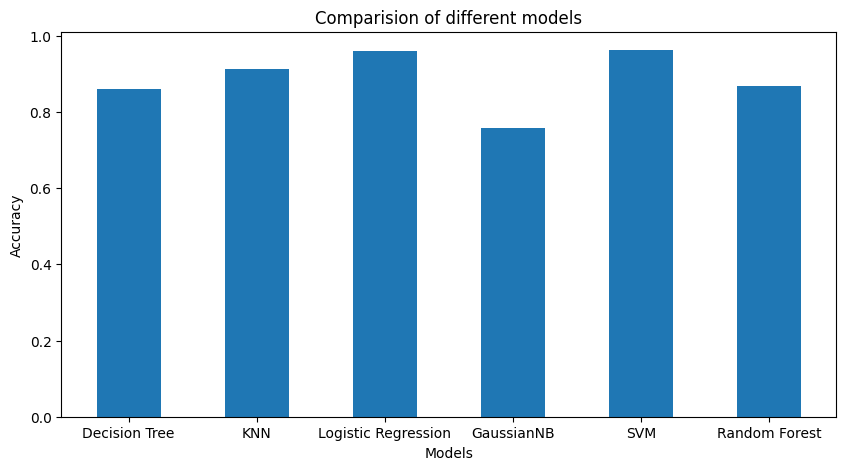

In [40]:
models = ['Decision Tree', 'KNN', 'Logistic Regression','GaussianNB', 'SVM', 'Random Forest']
accuracies = [dt_ac, knn_ac, lr_ac, gnb_ac, svm_ac, rf_ac]

plt.figure(figsize=(10,5))
plt.bar(models,accuracies, width=0.5)

plt.title('Comparision of different models')
plt.xlabel('Models')
plt.ylabel('Accuracy')

### **END OF CODE**